<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/XAI_extended_RSF_feature_imp_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 163.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

Mounted at /content/drive


In [ ]:
BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/combined_survival_model_ready_wout_protocol/"
)

TRAIN_PATH = BASE_DIR / "combined_train_survival_model_ready.csv"
VALIDATION_PATH = BASE_DIR / "combined_validation_survival_model_ready.csv"
TEST_PATH = BASE_DIR / "combined_test_survival_model_ready.csv"

XAI_OUTPUT_DIR = BASE_DIR / "rsf_xai"
XAI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (620, 68)
Validation: (177, 68)
Test: (89, 68)


In [ ]:
DURATION_COL = "OS_DAYS"
EVENT_COL = "OS_EVENT"

PATIENT_ID_COL = "PATIENT_ID"
SAMPLE_ID_COL = "SAMPLE_ID"

EXCLUDED_COLUMNS = [
    PATIENT_ID_COL,
    SAMPLE_ID_COL,
    DURATION_COL,
    EVENT_COL,
]

In [ ]:
candidate_features = [
    column
    for column in train_df.columns
    if column not in EXCLUDED_COLUMNS
]

# Keep numeric features only
candidate_features = [
    column
    for column in candidate_features
    if pd.api.types.is_numeric_dtype(train_df[column])
]

# Remove zero-variance predictors based on TRAINING set only
zero_variance_features = [
    feature
    for feature in candidate_features
    if train_df[feature].nunique(dropna=True) <= 1
]

MODEL_FEATURES = [
    feature
    for feature in candidate_features
    if feature not in zero_variance_features
]

print("Number of model features:", len(MODEL_FEATURES))
print("\nFeatures:")
for feature in MODEL_FEATURES:
    print("-", feature)

Number of model features: 64

Features:
- AGE
- BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE
- PERIPHERAL_BLASTS_PERCENTAGE
- WBC_LOG1P
- SEX_Female
- SEX_Male
- RACE_American Indian or Alaska Native
- RACE_Asian
- RACE_Black or African American
- RACE_Native Hawaiian or other Pacific Islander
- RACE_Other
- RACE_White
- ETHNICITY_Hispanic or Latino
- ETHNICITY_Not Hispanic or Latino
- CNS_DISEASE_No
- CNS_DISEASE_Yes
- CHLOROMA_No
- CHLOROMA_Yes
- FAB_M0
- FAB_M1
- FAB_M2
- FAB_M4
- FAB_M5
- FAB_M6
- FAB_M7
- FAB_NOS
- PRIMARY_CYTOGENETIC_CODE_MLL
- PRIMARY_CYTOGENETIC_CODE_Normal
- PRIMARY_CYTOGENETIC_CODE_Other
- PRIMARY_CYTOGENETIC_CODE_inv(16)
- PRIMARY_CYTOGENETIC_CODE_t(8;21)
- RISK_GROUP_CLEAN_High
- RISK_GROUP_CLEAN_Low
- RISK_GROUP_CLEAN_Missing
- RISK_GROUP_CLEAN_Standard
- CYTOGENETIC_COMPLEXITY_GROUP_0
- CYTOGENETIC_COMPLEXITY_GROUP_1
- CYTOGENETIC_COMPLEXITY_GROUP_2
- CYTOGENETIC_COMPLEXITY_GROUP_3
- CYTOGENETIC_COMPLEXITY_GROUP_4_plus
- T_6_9
- T_8_21
- T_3_5_Q25_Q34
- T_6_11_Q

In [ ]:
def prepare_X(df):
    X = df[MODEL_FEATURES].copy()

    for feature in MODEL_FEATURES:
        X[feature] = pd.to_numeric(
            X[feature],
            errors="raise"
        ).astype(float)

    return X


def prepare_y(df):
    return Surv.from_arrays(
        event=df[EVENT_COL].astype(bool).to_numpy(),
        time=df[DURATION_COL].astype(float).to_numpy()
    )

In [ ]:
X_train = prepare_X(train_df)
X_validation = prepare_X(validation_df)
X_test = prepare_X(test_df)

y_train = prepare_y(train_df)
y_validation = prepare_y(validation_df)
y_test = prepare_y(test_df)

In [ ]:
FINAL_RSF_CONFIG = {
    "n_estimators": 500,
    "max_depth": 6,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "bootstrap": True,
    "oob_score": True,
    "n_jobs": -1,
    "random_state": 42,
}

In [ ]:
rsf = RandomSurvivalForest(
    **FINAL_RSF_CONFIG
)

rsf.fit(
    X_train,
    y_train
)

print("RSF fitted successfully.")
print("OOB C-index:", round(rsf.oob_score_, 4))

RSF fitted successfully.
OOB C-index: 0.6467


In [ ]:
def get_c_index(model, X, y):
    risk_scores = model.predict(X)

    return concordance_index_censored(
        y["event"],
        y["time"],
        risk_scores
    )[0]

In [ ]:
train_cindex = get_c_index(
    rsf,
    X_train,
    y_train
)

val_cindex = get_c_index(
    rsf,
    X_validation,
    y_validation
)

test_cindex = get_c_index(
    rsf,
    X_test,
    y_test
)

print(f"Train C-index:      {train_cindex:.4f}")
print(f"Validation C-index: {val_cindex:.4f}")
print(f"Test C-index:       {test_cindex:.4f}")

Train C-index:      0.7903
Validation C-index: 0.6962
Test C-index:       0.6841


In [ ]:
def survival_cindex_scorer(model, X, y):
    risk_scores = model.predict(X)

    return concordance_index_censored(
        y["event"],
        y["time"],
        risk_scores
    )[0]

In [ ]:
perm_results = permutation_importance(
    estimator=rsf,
    X=X_validation,
    y=y_validation,
    scoring=survival_cindex_scorer,
    n_repeats=50,
    random_state=42,
    n_jobs=-1,
)

In [ ]:
importance_df = pd.DataFrame({
    "Feature": MODEL_FEATURES,
    "Importance_Mean": perm_results.importances_mean,
    "Importance_SD": perm_results.importances_std,
})

importance_df = (
    importance_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

#display(importance_df)

# Select top 20
top20_importance_df = importance_df.head(20)

print("Top 20 Most Important Features:")
display(top20_importance_df)

Top 20 Most Important Features:


,Feature,Importance_Mean,Importance_SD
0,RISK_GROUP_CLEAN_Low,0.036711,0.013288
1,RACE_Black or African American,0.010403,0.010804
2,MONOSOMY_7,0.006877,0.003141
3,T_10_11_P11_2_Q23,0.006300,0.001626
4,AGE,0.005728,0.004009
5,PRIMARY_CYTOGENETIC_CODE_Other,0.005455,0.005456
6,RISK_GROUP_CLEAN_Standard,0.004810,0.004442
7,PERIPHERAL_BLASTS_PERCENTAGE,0.004638,0.005857
8,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.004194,0.003851
9,CYTOGENETIC_COMPLEXITY_GROUP_1,0.003381,0.002303


In [ ]:
importance_df = pd.DataFrame({
    "Feature": MODEL_FEATURES,
    "Importance_Mean": perm_results.importances_mean,
    "Importance_SD": perm_results.importances_std,
})

# Calculate Mean / SD ratio
importance_df["Mean/SD_Ratio"] = (
    importance_df["Importance_Mean"] /
    importance_df["Importance_SD"]
)

# Sort by mean permutation importance
importance_df = (
    importance_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

# Select top 20
top20_importance_df = importance_df.head(20)

print("Top 20 Most Important Features:")
display(top20_importance_df)

Top 20 Most Important Features:


,Feature,Importance_Mean,Importance_SD,Mean/SD_Ratio
0,RISK_GROUP_CLEAN_Low,0.036711,0.013288,2.762829
1,RACE_Black or African American,0.010403,0.010804,0.962883
2,MONOSOMY_7,0.006877,0.003141,2.189571
3,T_10_11_P11_2_Q23,0.006300,0.001626,3.875010
4,AGE,0.005728,0.004009,1.428809
5,PRIMARY_CYTOGENETIC_CODE_Other,0.005455,0.005456,0.999942
6,RISK_GROUP_CLEAN_Standard,0.004810,0.004442,1.082858
7,PERIPHERAL_BLASTS_PERCENTAGE,0.004638,0.005857,0.791919
8,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.004194,0.003851,1.088892
9,CYTOGENETIC_COMPLEXITY_GROUP_1,0.003381,0.002303,1.468136


In [ ]:
importance_df.to_csv(
    XAI_OUTPUT_DIR / "rsf_permutation_importance_validation.csv",
    index=False
)

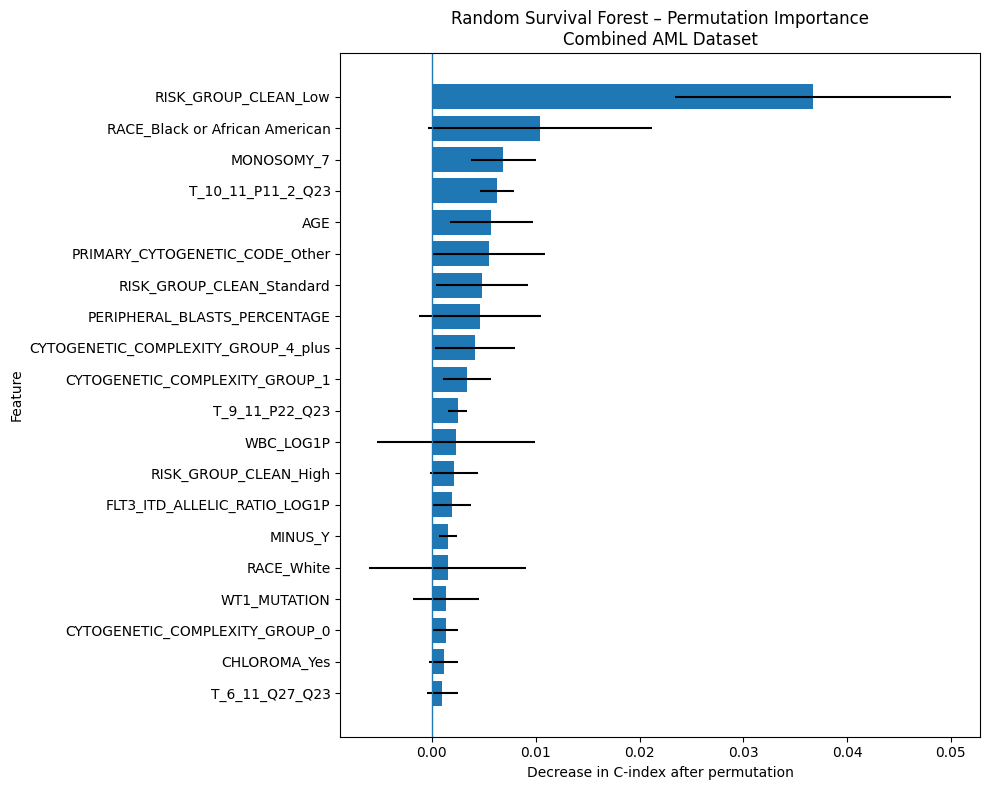

In [ ]:
TOP_N = 20

plot_df = (
    importance_df
    .head(TOP_N)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance_Mean"],
    xerr=plot_df["Importance_SD"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Decrease in C-index after permutation")
plt.ylabel("Feature")

plt.title(
    "Random Survival Forest – Permutation Importance\n"
    "Combined AML Dataset"
)

plt.tight_layout()

plt.savefig(
    XAI_OUTPUT_DIR / "rsf_permutation_importance_top20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

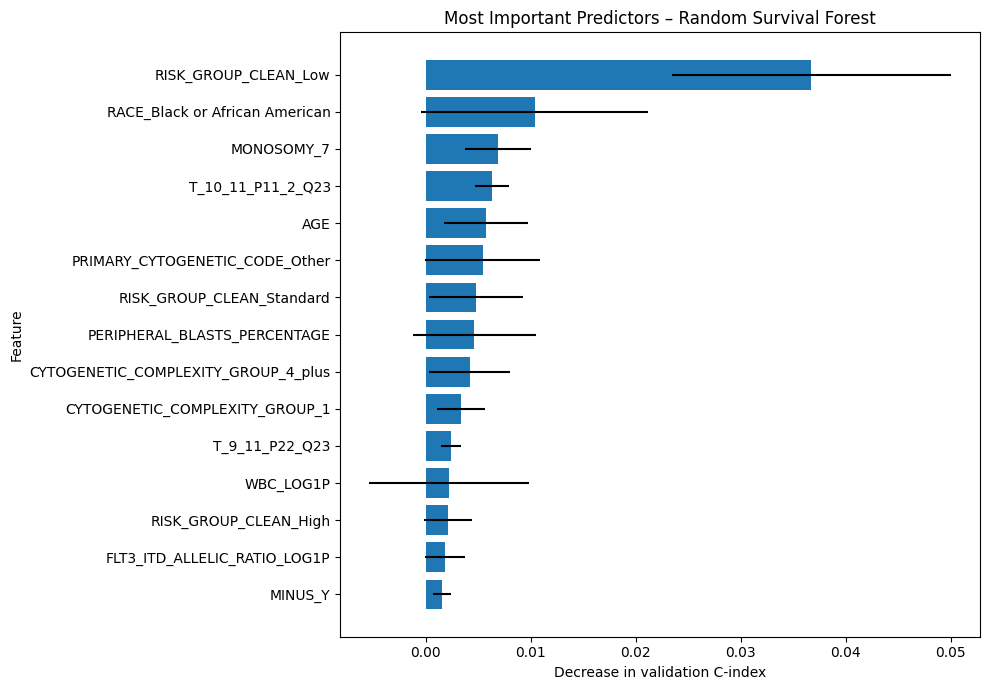

In [ ]:
positive_importance_df = importance_df[
    importance_df["Importance_Mean"] > 0
].copy()

TOP_N = min(
    15,
    len(positive_importance_df)
)

plot_df = (
    positive_importance_df
    .head(TOP_N)
    .sort_values("Importance_Mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance_Mean"],
    xerr=plot_df["Importance_SD"]
)

plt.xlabel("Decrease in validation C-index")
plt.ylabel("Feature")

plt.title(
    "Most Important Predictors – Random Survival Forest"
)

plt.tight_layout()
plt.show()

In [ ]:
test_perm_results = permutation_importance(
    estimator=rsf,
    X=X_test,
    y=y_test,
    scoring=survival_cindex_scorer,
    n_repeats=50,
    random_state=42,
    n_jobs=-1,
)

In [ ]:
test_importance_df = pd.DataFrame({
    "Feature": MODEL_FEATURES,
    "Test_Importance_Mean":
        test_perm_results.importances_mean,
    "Test_Importance_SD":
        test_perm_results.importances_std,
})

test_importance_df = (
    test_importance_df
    .sort_values(
        "Test_Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(test_importance_df.head(20))

,Feature,Test_Importance_Mean,Test_Importance_SD
0,RISK_GROUP_CLEAN_Low,0.051276,0.023642
1,PRIMARY_CYTOGENETIC_CODE_Other,0.020436,0.007994
2,AGE,0.019555,0.008229
3,RACE_Black or African American,0.019047,0.013538
4,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.012855,0.008554
5,RISK_GROUP_CLEAN_Standard,0.008870,0.007317
6,FAB_M0,0.006074,0.001725
7,WBC_LOG1P,0.005420,0.011646
8,MONOSOMY_7,0.003904,0.003270
9,INV_16,0.003323,0.005720


In [ ]:
test_importance_df = pd.DataFrame({
    "Feature": MODEL_FEATURES,

    "Test_Importance_Mean":
        test_perm_results.importances_mean,

    "Test_Importance_SD":
        test_perm_results.importances_std,
})

# Calculate Mean / SD ratio
test_importance_df["Mean_SD_Ratio"] = (
    test_importance_df["Test_Importance_Mean"]
    / test_importance_df["Test_Importance_SD"]
)

# Sort by Mean Importance
test_importance_df = (
    test_importance_df
    .sort_values(
        "Test_Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display Top 20
display(test_importance_df.head(20))

,Feature,Test_Importance_Mean,Test_Importance_SD,Mean_SD_Ratio
0,RISK_GROUP_CLEAN_Low,0.051276,0.023642,2.168798
1,PRIMARY_CYTOGENETIC_CODE_Other,0.020436,0.007994,2.556389
2,AGE,0.019555,0.008229,2.376256
3,RACE_Black or African American,0.019047,0.013538,1.406915
4,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.012855,0.008554,1.502778
5,RISK_GROUP_CLEAN_Standard,0.008870,0.007317,1.212173
6,FAB_M0,0.006074,0.001725,3.521589
7,WBC_LOG1P,0.005420,0.011646,0.465379
8,MONOSOMY_7,0.003904,0.003270,1.193984
9,INV_16,0.003323,0.005720,0.580920


In [ ]:
comparison_df = importance_df.merge(
    test_importance_df,
    on="Feature"
)

comparison_df["Val_Rank"] = (
    comparison_df["Importance_Mean"]
    .rank(
        ascending=False,
        method="average"
    )
)

comparison_df["Test_Rank"] = (
    comparison_df["Test_Importance_Mean"]
    .rank(
        ascending=False,
        method="average"
    )
)

In [ ]:
spearman_corr, spearman_p = spearmanr(
    comparison_df["Val_Rank"],
    comparison_df["Test_Rank"]
)

print(
    f"Spearman rank correlation: "
    f"{spearman_corr:.3f}"
)

print(
    f"p-value: {spearman_p:.4g}"
)

Spearman rank correlation: 0.418
p-value: 0.0005861


In [ ]:
TOP_K = 10

top_val = set(
    importance_df
    .head(TOP_K)["Feature"]
)

top_test = set(
    test_importance_df
    .head(TOP_K)["Feature"]
)

intersection = top_val & top_test
union = top_val | top_test

jaccard = (
    len(intersection)
    / len(union)
)

print("Validation top 10:")
print(top_val)

print("\nTest top 10:")
print(top_test)

print("\nCommon features:")
print(intersection)

print(
    f"\nTop-{TOP_K} Jaccard similarity: "
    f"{jaccard:.3f}"
)

Validation top 10:
{'RACE_Black or African American', 'CYTOGENETIC_COMPLEXITY_GROUP_1', 'RISK_GROUP_CLEAN_Low', 'PERIPHERAL_BLASTS_PERCENTAGE', 'MONOSOMY_7', 'AGE', 'PRIMARY_CYTOGENETIC_CODE_Other', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'T_10_11_P11_2_Q23', 'RISK_GROUP_CLEAN_Standard'}

Test top 10:
{'RACE_Black or African American', 'INV_16', 'RISK_GROUP_CLEAN_Low', 'MONOSOMY_7', 'AGE', 'FAB_M0', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'PRIMARY_CYTOGENETIC_CODE_Other', 'RISK_GROUP_CLEAN_Standard', 'WBC_LOG1P'}

Common features:
{'RACE_Black or African American', 'RISK_GROUP_CLEAN_Low', 'AGE', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'PRIMARY_CYTOGENETIC_CODE_Other', 'MONOSOMY_7', 'RISK_GROUP_CLEAN_Standard'}

Top-10 Jaccard similarity: 0.538


In [ ]:
baseline_cindex = get_c_index(
    rsf,
    X_validation,
    y_validation
)

print(
    "Baseline validation C-index:",
    round(baseline_cindex, 4)
)

Baseline validation C-index: 0.6962


In [ ]:
rng = np.random.default_rng(42)

TOP_K_VALUES = [
    1,
    3,
    5,
    10,
    15
]

faithfulness_results = []

ranked_features = (
    importance_df["Feature"]
    .tolist()
)

for k in TOP_K_VALUES:

    X_permuted = X_validation.copy()

    top_features = ranked_features[:k]

    for feature in top_features:
        X_permuted[feature] = rng.permutation(
            X_permuted[feature].values
        )

    permuted_cindex = get_c_index(
        rsf,
        X_permuted,
        y_validation
    )

    cindex_drop = (
        baseline_cindex
        - permuted_cindex
    )

    faithfulness_results.append({
        "Top_K_Features_Permuted": k,
        "C_Index": permuted_cindex,
        "C_Index_Drop": cindex_drop
    })

In [ ]:
faithfulness_df = pd.DataFrame(
    faithfulness_results
)

display(faithfulness_df)

,Top_K_Features_Permuted,C_Index,C_Index_Drop
0,1,0.650039,0.046157
1,3,0.642704,0.053493
2,5,0.638528,0.057668
3,10,0.590678,0.105519
4,15,0.537073,0.159124


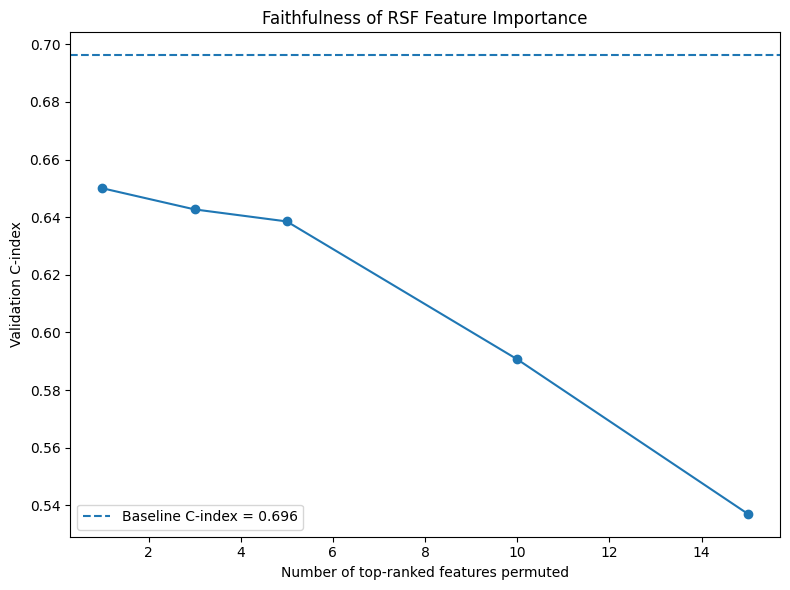

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    faithfulness_df["Top_K_Features_Permuted"],
    faithfulness_df["C_Index"],
    marker="o"
)

plt.axhline(
    baseline_cindex,
    linestyle="--",
    label=(
        f"Baseline C-index = "
        f"{baseline_cindex:.3f}"
    )
)

plt.xlabel(
    "Number of top-ranked features permuted"
)

plt.ylabel(
    "Validation C-index"
)

plt.title(
    "Faithfulness of RSF Feature Importance"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    XAI_OUTPUT_DIR / "rsf_feature_importance_faithfulness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
baseline_row = pd.DataFrame({
    "Top-K Features Permuted": [0],
    "C-Index": [round(baseline_cindex, 3)],
    "C-Index Drop": [0.000]
})

faithfulness_table = pd.concat(
    [baseline_row, faithfulness_table],
    ignore_index=True
)

display(faithfulness_table)

NameError: name 'faithfulness_table' is not defined

In [ ]:
# bootstrap

In [ ]:
N_BOOTSTRAPS = 200
N_PERM_REPEATS = 20

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd

N_BOOTSTRAPS = 200
N_PERM_REPEATS = 20
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

n_val = len(X_validation)

bootstrap_importances = []

for b in range(N_BOOTSTRAPS):

    # Sample validation patients WITH replacement
    bootstrap_idx = rng.choice(
        n_val,
        size=n_val,
        replace=True
    )

    X_boot = X_validation.iloc[
        bootstrap_idx
    ].reset_index(drop=True)

    y_boot = y_validation[
        bootstrap_idx
    ]

    # Permutation importance within bootstrap sample
    boot_perm = permutation_importance(
        estimator=rsf,
        X=X_boot,
        y=y_boot,
        scoring=survival_cindex_scorer,
        n_repeats=N_PERM_REPEATS,
        random_state=RANDOM_SEED + b,
        n_jobs=-1
    )

    bootstrap_importances.append(
        boot_perm.importances_mean
    )

    if (b + 1) % 20 == 0:
        print(
            f"Completed {b + 1}/{N_BOOTSTRAPS}"
        )

Completed 20/200
Completed 40/200
Completed 60/200
Completed 80/200
Completed 100/200
Completed 120/200
Completed 140/200
Completed 160/200
Completed 180/200
Completed 200/200


In [ ]:
bootstrap_importances = np.asarray(
    bootstrap_importances
)

print(
    "Bootstrap matrix shape:",
    bootstrap_importances.shape
)

Bootstrap matrix shape: (200, 64)


In [ ]:
ci_lower = np.percentile(
    bootstrap_importances,
    2.5,
    axis=0
)

ci_upper = np.percentile(
    bootstrap_importances,
    97.5,
    axis=0
)

In [ ]:
importance_ci_df = pd.DataFrame({
    "Feature":
        MODEL_FEATURES,

    "Importance_Mean":
        perm_results.importances_mean,

    "Importance_SD":
        perm_results.importances_std,

    "CI_2.5%":
        ci_lower,

    "CI_97.5%":
        ci_upper
})

In [ ]:
importance_ci_df = (
    importance_ci_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "RSF Permutation Importance "
    "with Bootstrap 95% CIs"
)

display(
    importance_ci_df.head(20)
)

RSF Permutation Importance with Bootstrap 95% CIs


,Feature,Importance_Mean,Importance_SD,CI_2.5%,CI_97.5%
0,RISK_GROUP_CLEAN_Low,0.036711,0.013288,0.015560,0.061218
1,RACE_Black or African American,0.010403,0.010804,-0.012329,0.030750
2,MONOSOMY_7,0.006877,0.003141,-0.002597,0.017503
3,T_10_11_P11_2_Q23,0.006300,0.001626,-0.000869,0.014031
4,AGE,0.005728,0.004009,-0.003754,0.016322
5,PRIMARY_CYTOGENETIC_CODE_Other,0.005455,0.005456,-0.004022,0.017118
6,RISK_GROUP_CLEAN_Standard,0.004810,0.004442,-0.003134,0.013985
7,PERIPHERAL_BLASTS_PERCENTAGE,0.004638,0.005857,-0.008229,0.017151
8,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.004194,0.003851,-0.002066,0.012880
9,CYTOGENETIC_COMPLEXITY_GROUP_1,0.003381,0.002303,-0.001516,0.008500


In [ ]:
importance_ci_df[
    "CI_Excludes_Zero"
] = (
    importance_ci_df["CI_2.5%"] > 0
)

In [ ]:
display(
    importance_ci_df.head(20)
)

,Feature,Importance_Mean,Importance_SD,CI_2.5%,CI_97.5%,CI_Excludes_Zero
0,RISK_GROUP_CLEAN_Low,0.036711,0.013288,0.015560,0.061218,True
1,RACE_Black or African American,0.010403,0.010804,-0.012329,0.030750,False
2,MONOSOMY_7,0.006877,0.003141,-0.002597,0.017503,False
3,T_10_11_P11_2_Q23,0.006300,0.001626,-0.000869,0.014031,False
4,AGE,0.005728,0.004009,-0.003754,0.016322,False
5,PRIMARY_CYTOGENETIC_CODE_Other,0.005455,0.005456,-0.004022,0.017118,False
6,RISK_GROUP_CLEAN_Standard,0.004810,0.004442,-0.003134,0.013985,False
7,PERIPHERAL_BLASTS_PERCENTAGE,0.004638,0.005857,-0.008229,0.017151,False
8,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.004194,0.003851,-0.002066,0.012880,False
9,CYTOGENETIC_COMPLEXITY_GROUP_1,0.003381,0.002303,-0.001516,0.008500,False


In [ ]:
top20 = importance_ci_df.head(20).copy()

top20 = top20.iloc[::-1]

lower_error = (
    top20["Importance_Mean"]
    - top20["CI_2.5%"]
).clip(lower=0)

upper_error = (
    top20["CI_97.5%"]
    - top20["Importance_Mean"]
).clip(lower=0)

plt.figure(
    figsize=(10, 8)
)

plt.errorbar(
    top20["Importance_Mean"],
    top20["Feature"],
    xerr=[
        lower_error,
        upper_error
    ],
    fmt="o",
    capsize=4
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Permutation Importance "
    "(C-index decrease)"
)

plt.ylabel("Feature")

plt.title(
    "RSF Permutation Importance "
    "with 95% Bootstrap CIs"
)

plt.tight_layout()
plt.show()

NameError: name 'importance_ci_df' is not defined

In [ ]:
# subgroup fairness

In [ ]:
import numpy as np
import pandas as pd

from sksurv.metrics import concordance_index_censored


# ============================================================
# 1. START FROM TEST DATA
# ============================================================

fairness_rsf_df = test_df.copy()


# ============================================================
# 2. LOAD RAW CLINICAL DATA
#    Only used to recover original AGE / SEX / RACE
# ============================================================

RAW_CLINICAL_PATH = (
     "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "AML Dataset/aml_target_2018_pub/data_clinical_patient.txt"
)

raw_df = pd.read_csv(
    RAW_CLINICAL_PATH,
    sep="\t",
    comment="#"
)


# ============================================================
# 3. CREATE DEMOGRAPHIC LOOKUP
# ============================================================

demographic_lookup = (
    raw_df[
        ["PATIENT_ID", "AGE", "SEX", "RACE"]
    ]
    .drop_duplicates("PATIENT_ID")
    .rename(
        columns={
            "AGE": "AGE_ORIGINAL",
            "SEX": "SEX_GROUP",
            "RACE": "RACE_GROUP"
        }
    )
)


# ============================================================
# 4. MERGE DEMOGRAPHICS WITH TEST PATIENTS
# ============================================================

n_before = len(fairness_rsf_df)

fairness_rsf_df = fairness_rsf_df.merge(
    demographic_lookup,
    on="PATIENT_ID",
    how="left",
    validate="one_to_one"
)

assert len(fairness_rsf_df) == n_before

print("Missing age:",
      fairness_rsf_df["AGE_ORIGINAL"].isna().sum())

print("Missing sex:",
      fairness_rsf_df["SEX_GROUP"].isna().sum())

print("Missing race:",
      fairness_rsf_df["RACE_GROUP"].isna().sum())

Missing age: 0
Missing sex: 0
Missing race: 0


In [ ]:
# ============================================================
# AGE GROUPS
# ============================================================

fairness_rsf_df["AGE_GROUP"] = pd.qcut(
    fairness_rsf_df["AGE_ORIGINAL"],
    q=3,
    labels=[
        "Younger",
        "Middle",
        "Older"
    ],
    duplicates="drop"
)

print(
    fairness_rsf_df["AGE_GROUP"]
    .value_counts()
    .sort_index()
)

AGE_GROUP
Younger    35
Middle     25
Older      29
Name: count, dtype: int64


In [ ]:
# ============================================================
# RSF TEST RISK PREDICTIONS
# ============================================================

rsf_test_risk = rsf.predict(X_test)

fairness_rsf_df["PREDICTED_RISK"] = rsf_test_risk

In [ ]:
def bootstrap_subgroup_cindex(
    df,
    group_column,
    n_bootstraps=1000,
    random_seed=42,
    min_n=5,
    min_events=2
):

    rng = np.random.default_rng(random_seed)

    results = []

    for group, subset in df.groupby(
        group_column,
        observed=True
    ):

        subset = subset.reset_index(drop=True)

        n = len(subset)
        events = int(subset["OS_EVENT"].sum())

        # ---------------------------------------------
        # Insufficient subgroup size
        # ---------------------------------------------

        if n < min_n or events < min_events:

            results.append({
                "Group": group,
                "N": n,
                "Events": events,
                "C_index": np.nan,
                "CI_2.5%": np.nan,
                "CI_97.5%": np.nan,
                "Valid_Bootstraps": 0
            })

            continue


        # ---------------------------------------------
        # Original subgroup C-index
        # ---------------------------------------------

        original_cindex = (
            concordance_index_censored(
                subset[
                    "OS_EVENT"
                ].astype(bool).values,

                subset[
                    "OS_DAYS"
                ].values,

                subset[
                    "PREDICTED_RISK"
                ].values
            )[0]
        )


        # ---------------------------------------------
        # Bootstrap
        # ---------------------------------------------

        bootstrap_cindices = []

        for b in range(n_bootstraps):

            bootstrap_idx = rng.choice(
                n,
                size=n,
                replace=True
            )

            boot = subset.iloc[
                bootstrap_idx
            ]

            # Too few events in this bootstrap sample
            if boot["OS_EVENT"].sum() < min_events:
                continue

            try:

                cindex = (
                    concordance_index_censored(
                        boot[
                            "OS_EVENT"
                        ].astype(bool).values,

                        boot[
                            "OS_DAYS"
                        ].values,

                        boot[
                            "PREDICTED_RISK"
                        ].values
                    )[0]
                )

                if np.isfinite(cindex):
                    bootstrap_cindices.append(
                        cindex
                    )

            except Exception:
                continue


        # ---------------------------------------------
        # 95% percentile CI
        # ---------------------------------------------

        if len(bootstrap_cindices) > 0:

            ci_lower = np.percentile(
                bootstrap_cindices,
                2.5
            )

            ci_upper = np.percentile(
                bootstrap_cindices,
                97.5
            )

        else:

            ci_lower = np.nan
            ci_upper = np.nan


        results.append({
            "Group": group,
            "N": n,
            "Events": events,
            "C_index": original_cindex,
            "CI_2.5%": ci_lower,
            "CI_97.5%": ci_upper,
            "Valid_Bootstraps":
                len(bootstrap_cindices)
        })


    return pd.DataFrame(results)

In [ ]:
# ============================================================
# SEX
# ============================================================

rsf_sex_results = bootstrap_subgroup_cindex(
    fairness_rsf_df,
    "SEX_GROUP",
    n_bootstraps=1000
)


# ============================================================
# AGE
# ============================================================

rsf_age_results = bootstrap_subgroup_cindex(
    fairness_rsf_df,
    "AGE_GROUP",
    n_bootstraps=1000
)


# ============================================================
# RACE
# ============================================================

rsf_race_results = bootstrap_subgroup_cindex(
    fairness_rsf_df,
    "RACE_GROUP",
    n_bootstraps=1000
)

In [ ]:
def add_ci_display(df):

    df = df.copy()

    df["C_index_95CI"] = df.apply(
        lambda row:
        (
            f"{row['C_index']:.3f} "
            f"[{row['CI_2.5%']:.3f}, "
            f"{row['CI_97.5%']:.3f}]"
        )
        if pd.notna(row["C_index"])
        and pd.notna(row["CI_2.5%"])
        else "Insufficient data",
        axis=1
    )

    return df


rsf_sex_results = add_ci_display(
    rsf_sex_results
)

rsf_age_results = add_ci_display(
    rsf_age_results
)

rsf_race_results = add_ci_display(
    rsf_race_results
)

In [ ]:
print("RSF — SEX")
display(
    rsf_sex_results[
        ["Group", "N", "Events", "C_index_95CI"]
    ]
)

print("RSF — AGE")
display(
    rsf_age_results[
        ["Group", "N", "Events", "C_index_95CI"]
    ]
)

print("RSF — RACE")
display(
    rsf_race_results[
        ["Group", "N", "Events", "C_index_95CI"]
    ]
)

RSF — SEX


,Group,N,Events,C_index_95CI
0,Female,44,14,"0.765 [0.626, 0.882]"
1,Male,45,18,"0.578 [0.424, 0.707]"


RSF — AGE


,Group,N,Events,C_index_95CI
0,Younger,35,15,"0.668 [0.488, 0.830]"
1,Middle,25,5,"0.742 [0.418, 0.975]"
2,Older,29,12,"0.598 [0.398, 0.776]"


RSF — RACE


,Group,N,Events,C_index_95CI
0,Asian,4,1,Insufficient data
1,Black or African American,9,5,"0.600 [0.238, 0.901]"
2,Other,7,2,"0.273 [0.000, 0.733]"
3,Unknown,3,1,Insufficient data
4,White,66,23,"0.736 [0.623, 0.832]"


In [ ]:
# ============================================================
# RSF FAIRNESS RESULTS — C-INDEX ONLY
# ============================================================

print("RSF — SEX")
display(
    rsf_sex_results[
        ["Group", "N", "Events", "C_index"]
    ].round(3)
)

print("RSF — AGE")
display(
    rsf_age_results[
        ["Group", "N", "Events", "C_index"]
    ].round(3)
)

print("RSF — RACE")
display(
    rsf_race_results[
        ["Group", "N", "Events", "C_index"]
    ].round(3)
)

RSF — SEX


,Group,N,Events,C_index
0,Female,44,14,0.765
1,Male,45,18,0.578


RSF — AGE


,Group,N,Events,C_index
0,Younger,35,15,0.668
1,Middle,25,5,0.742
2,Older,29,12,0.598


RSF — RACE


,Group,N,Events,C_index
0,Asian,4,1,NaN
1,Black or African American,9,5,0.600
2,Other,7,2,0.273
3,Unknown,3,1,NaN
4,White,66,23,0.736


In [ ]:
#---------

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# RSF MODEL OUTPUTS
# ============================================================

HORIZONS = {
    "1Y": 365,
    "2Y": 730,
    "3Y": 1095
}

# Risk score
fairness_rsf_df["PREDICTED_RISK"] = rsf.predict(X_test)


# RSF predicted survival functions
survival_functions = rsf.predict_survival_function(
    X_test
)


# Extract survival probability at a specific horizon
def get_survival_probability(surv_fn, horizon):
    return float(surv_fn(horizon))


for label, horizon in HORIZONS.items():

    fairness_rsf_df[f"SURVIVAL_{label}"] = [
        get_survival_probability(
            surv_fn,
            horizon
        )
        for surv_fn in survival_functions
    ]


display(
    fairness_rsf_df[
        [
            "PATIENT_ID",
            "PREDICTED_RISK",
            "SURVIVAL_1Y",
            "SURVIVAL_2Y",
            "SURVIVAL_3Y"
        ]
    ].head()
)

,PATIENT_ID,PREDICTED_RISK,SURVIVAL_1Y,SURVIVAL_2Y,SURVIVAL_3Y
0,TARGET-21-PANVPB,53.907364,0.808660,0.676094,0.619003
1,TARGET-20-PASHZX,39.464217,0.869999,0.748341,0.696113
2,TARGET-20-PASKFN,18.411017,0.925741,0.876435,0.861340
3,TARGET-20-PATAST,22.701346,0.909661,0.842690,0.830866
4,TARGET-20-PASYRE,40.545828,0.847882,0.749499,0.694697


In [ ]:
assert np.all(
    fairness_rsf_df["SURVIVAL_1Y"]
    >= fairness_rsf_df["SURVIVAL_2Y"]
)

assert np.all(
    fairness_rsf_df["SURVIVAL_2Y"]
    >= fairness_rsf_df["SURVIVAL_3Y"]
)

print("Survival probabilities look consistent.")

Survival probabilities look consistent.


In [ ]:
from sksurv.metrics import brier_score


# ============================================================
# STRUCTURED SURVIVAL ARRAYS
# ============================================================

y_train_fair = np.array(
    list(
        zip(
            train_df["OS_EVENT"].astype(bool),
            train_df["OS_DAYS"].astype(float)
        )
    ),
    dtype=[
        ("event", "?"),
        ("time", "<f8")
    ]
)

In [ ]:
def rsf_subgroup_brier(
    df,
    group_column,
    y_train,
    min_n=5
):

    results = []

    for group, subset in df.groupby(
        group_column,
        observed=True
    ):

        n = len(subset)
        events = int(
            subset["OS_EVENT"].sum()
        )

        if n < min_n:

            results.append({
                "Group": group,
                "N": n,
                "Events": events,
                "BS_1Y": np.nan,
                "BS_2Y": np.nan,
                "BS_3Y": np.nan
            })

            continue


        # Survival outcome for this subgroup
        y_subgroup = np.array(
            list(
                zip(
                    subset[
                        "OS_EVENT"
                    ].astype(bool),

                    subset[
                        "OS_DAYS"
                    ].astype(float)
                )
            ),
            dtype=[
                ("event", "?"),
                ("time", "<f8")
            ]
        )


        # Prediction matrix:
        # rows = patients
        # columns = 1Y, 2Y, 3Y
        subgroup_survival = subset[
            [
                "SURVIVAL_1Y",
                "SURVIVAL_2Y",
                "SURVIVAL_3Y"
            ]
        ].to_numpy()


        try:

            _, scores = brier_score(
                y_train,
                y_subgroup,
                subgroup_survival,
                np.array(
                    [365., 730., 1095.]
                )
            )

            results.append({
                "Group": group,
                "N": n,
                "Events": events,
                "BS_1Y": scores[0],
                "BS_2Y": scores[1],
                "BS_3Y": scores[2]
            })

        except Exception as e:

            print(
                f"{group}: Brier Score "
                f"could not be calculated: {e}"
            )

            results.append({
                "Group": group,
                "N": n,
                "Events": events,
                "BS_1Y": np.nan,
                "BS_2Y": np.nan,
                "BS_3Y": np.nan
            })


    return pd.DataFrame(results)

In [ ]:
rsf_sex_brier = rsf_subgroup_brier(
    fairness_rsf_df,
    "SEX_GROUP",
    y_train_fair
)

rsf_age_brier = rsf_subgroup_brier(
    fairness_rsf_df,
    "AGE_GROUP",
    y_train_fair
)

rsf_race_brier = rsf_subgroup_brier(
    fairness_rsf_df,
    "RACE_GROUP",
    y_train_fair
)


print("RSF — SEX")
display(rsf_sex_brier.round(3))

print("RSF — AGE")
display(rsf_age_brier.round(3))

print("RSF — RACE")
display(rsf_race_brier.round(3))

RSF — SEX


,Group,N,Events,BS_1Y,BS_2Y,BS_3Y
0,Female,44,14,0.140,0.169,0.172
1,Male,45,18,0.089,0.209,0.224


RSF — AGE


,Group,N,Events,BS_1Y,BS_2Y,BS_3Y
0,Younger,35,15,0.131,0.224,0.231
1,Middle,25,5,0.066,0.122,0.122
2,Older,29,12,0.137,0.205,0.225


RSF — RACE


,Group,N,Events,BS_1Y,BS_2Y,BS_3Y
0,Asian,4,1,NaN,NaN,NaN
1,Black or African American,9,5,0.204,0.219,0.258
2,Other,7,2,0.132,0.258,0.267
3,Unknown,3,1,NaN,NaN,NaN
4,White,66,23,0.090,0.177,0.182


In [ ]:
from sksurv.nonparametric import kaplan_meier_estimator


def km_survival_at_time(
    events,
    durations,
    horizon
):

    times, survival = (
        kaplan_meier_estimator(
            events.astype(bool),
            durations.astype(float)
        )
    )

    valid = times <= horizon

    if not np.any(valid):
        return 1.0

    return survival[valid][-1]

In [ ]:
def rsf_subgroup_calibration(
    df,
    group_column,
    min_n=5
):

    results = []

    for group, subset in df.groupby(
        group_column,
        observed=True
    ):

        if len(subset) < min_n:
            continue

        row = {
            "Group": group,
            "N": len(subset)
        }


        for label, horizon in HORIZONS.items():

            predicted = subset[
                f"SURVIVAL_{label}"
            ].mean()

            observed = km_survival_at_time(
                subset["OS_EVENT"].values,
                subset["OS_DAYS"].values,
                horizon
            )

            row[
                f"Predicted_{label}"
            ] = predicted

            row[
                f"Observed_{label}"
            ] = observed


        results.append(row)


    return pd.DataFrame(results)

In [ ]:
rsf_sex_calibration = (
    rsf_subgroup_calibration(
        fairness_rsf_df,
        "SEX_GROUP"
    )
)

rsf_age_calibration = (
    rsf_subgroup_calibration(
        fairness_rsf_df,
        "AGE_GROUP"
    )
)

rsf_race_calibration = (
    rsf_subgroup_calibration(
        fairness_rsf_df,
        "RACE_GROUP"
    )
)


print("RSF — SEX CALIBRATION")
display(
    rsf_sex_calibration.round(3)
)

print("RSF — AGE CALIBRATION")
display(
    rsf_age_calibration.round(3)
)

print("RSF — RACE CALIBRATION")
display(
    rsf_race_calibration.round(3)
)

RSF — SEX CALIBRATION


,Group,N,Predicted_1Y,Observed_1Y,Predicted_2Y,Observed_2Y,Predicted_3Y,Observed_3Y
0,Female,44,0.841,0.792,0.722,0.722,0.682,0.697
1,Male,45,0.840,0.909,0.720,0.676,0.672,0.605


RSF — AGE CALIBRATION


,Group,N,Predicted_1Y,Observed_1Y,Predicted_2Y,Observed_2Y,Predicted_3Y,Observed_3Y
0,Younger,35,0.835,0.824,0.714,0.618,0.668,0.559
1,Middle,25,0.856,0.917,0.748,0.833,0.713,0.833
2,Older,29,0.833,0.828,0.706,0.684,0.656,0.612


RSF — RACE CALIBRATION


,Group,N,Predicted_1Y,Observed_1Y,Predicted_2Y,Observed_2Y,Predicted_3Y,Observed_3Y
0,Black or African American,9,0.752,0.667,0.611,0.556,0.549,0.444
1,Other,7,0.871,0.857,0.751,0.714,0.721,0.714
2,White,66,0.851,0.891,0.737,0.716,0.694,0.667


In [ ]:
from scipy.stats import (
    mannwhitneyu,
    kruskal
)


stat_results_rsf = []


# ============================================================
# SEX — MANN-WHITNEY U
# ============================================================

female = fairness_rsf_df[
    fairness_rsf_df[
        "SEX_GROUP"
    ] == "Female"
]

male = fairness_rsf_df[
    fairness_rsf_df[
        "SEX_GROUP"
    ] == "Male"
]


stat, p = mannwhitneyu(
    female["PREDICTED_RISK"],
    male["PREDICTED_RISK"],
    alternative="two-sided"
)


stat_results_rsf.append({
    "Subgroup": "Sex",
    "Groups": "Female vs Male",
    "Test": "Mann–Whitney U",
    "Statistic": stat,
    "p_value": p,
    "Significant":
        "Yes" if p < 0.05 else "No"
})

In [ ]:
# ============================================================
# AGE — KRUSKAL-WALLIS
# ============================================================

younger = fairness_rsf_df[
    fairness_rsf_df[
        "AGE_GROUP"
    ] == "Younger"
]

middle = fairness_rsf_df[
    fairness_rsf_df[
        "AGE_GROUP"
    ] == "Middle"
]

older = fairness_rsf_df[
    fairness_rsf_df[
        "AGE_GROUP"
    ] == "Older"
]


stat, p = kruskal(
    younger["PREDICTED_RISK"],
    middle["PREDICTED_RISK"],
    older["PREDICTED_RISK"]
)


stat_results_rsf.append({
    "Subgroup": "Age",
    "Groups":
        "Younger / Middle / Older",
    "Test": "Kruskal–Wallis",
    "Statistic": stat,
    "p_value": p,
    "Significant":
        "Yes" if p < 0.05 else "No"
})

In [ ]:
# ============================================================
# RACE — KRUSKAL-WALLIS
#
# Same rule as XGBoost:
# exclude Unknown and require at least 5 patients
# ============================================================

race_counts = (
    fairness_rsf_df[
        "RACE_GROUP"
    ].value_counts()
)


valid_races = race_counts[
    race_counts >= 5
].index.tolist()


valid_races = [
    race
    for race in valid_races
    if race != "Unknown"
]


race_groups = [
    fairness_rsf_df.loc[
        fairness_rsf_df[
            "RACE_GROUP"
        ] == race,
        "PREDICTED_RISK"
    ].values

    for race in valid_races
]


if len(race_groups) >= 2:

    stat, p = kruskal(
        *race_groups
    )

    stat_results_rsf.append({
        "Subgroup": "Race",
        "Groups":
            " / ".join(valid_races),
        "Test": "Kruskal–Wallis",
        "Statistic": stat,
        "p_value": p,
        "Significant":
            "Yes" if p < 0.05 else "No"
    })

else:

    stat_results_rsf.append({
        "Subgroup": "Race",
        "Groups":
            "Insufficient groups",
        "Test": "Kruskal–Wallis",
        "Statistic": np.nan,
        "p_value": np.nan,
        "Significant":
            "Not evaluated"
    })

In [ ]:
rsf_statistical_tests = pd.DataFrame(
    stat_results_rsf
)


rsf_statistical_tests[
    "Statistic"
] = (
    rsf_statistical_tests[
        "Statistic"
    ].round(3)
)


rsf_statistical_tests[
    "p_value"
] = (
    rsf_statistical_tests[
        "p_value"
    ].round(4)
)


display(
    rsf_statistical_tests
)

,Subgroup,Groups,Test,Statistic,p_value,Significant
0,Sex,Female vs Male,Mann–Whitney U,946.000,0.7211,No
1,Age,Younger / Middle / Older,Kruskal–Wallis,3.409,0.1819,No
2,Race,White / Black or African American / Other,Kruskal–Wallis,13.021,0.0015,Yes
